In [127]:
import numpy as np
import matplotlib.pyplot as plt


## Analytisk løsning — endelig stav med fastholdte ender

Ficks 2. lov på $[-L, L]$ med $L = 1$ mm:

$$\frac{\partial C}{\partial t}=D\frac{\partial^2C}{\partial x^2}$$

**GB:** $C(-L,t)=1$, $C(L,t)=0$ &nbsp;&nbsp; **IB:** $C(x,0)=1$ for $x<0$, $0$ for $x>0$

### Framgangsmåte

1. **Sluttilstand.** $C''=0$ gir $C_{ss}(x)=\tfrac12-\tfrac{x}{2L}$.
2. **Split av** med $u=C-C_{ss}$, slik at $u(\pm L,t)=0$. Da er $u_0(x)=\tfrac{x}{2L}-\tfrac12\operatorname{sgn}(x)$, som er odde om $x=0$.
3. **Separasjon av variable** på $u$: $T'=-\lambda DT$ og $X''=-\lambda X$. Randbetingelsene gir $k=m\pi/L$; cosinus-modene faller bort fordi $u_0$ er odde.
4. **Ortogonalitet** gir $a_m=\tfrac1L\int_{-L}^{L}u_0\sin\tfrac{m\pi x}{L}dx=-\tfrac{1}{m\pi}$.

### Resultat

$$C(x,t)=\frac{1}{2}-\frac{x}{2L}-\frac{1}{\pi}\sum_{m=1}^{\infty}\frac{1}{m}\sin\!\left(\frac{m\pi x}{L}\right)\exp\!\left(-\frac{m^2\pi^2Dt}{L^2}\right)$$

Første ledd er sluttilstanden (en rett rampe — ikke $\tfrac12$ overalt, siden endene holdes fast), andre ledd er avviket som dør ut. Mode $m$ har levetid $\tau_m = L^2/(m^2\pi^2 D)$.



[]

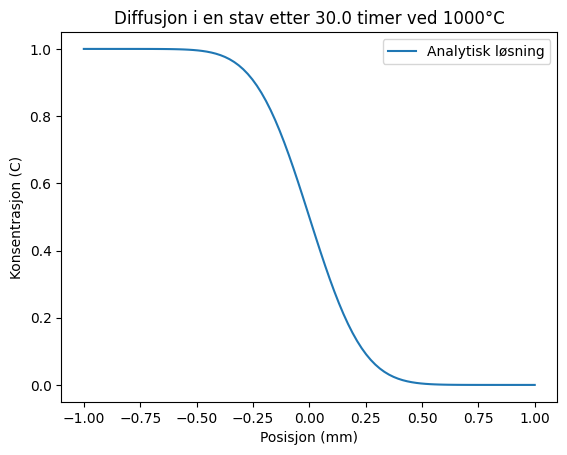

In [133]:
#Analytisk løsning

#------------- Parametere --------
R = 8.314          # J/(mol*K), gasskonstanten
D0, Q = 2.0e-5, 197e3  # Tabell 2.2 i P&E, Cu* i Cu
L = 1e-3           # m, avstand fra sentrum til enden av staven

def D_arrhenius(D0, Q, T):
    # Arrhenius: D = D0 * exp(-Q/RT)
    return D0 * np.exp(-Q / (R * T))


def analytical_solution(x, t, T, M=500):
    # Sluttilstanden: rett rampe fra C=1 ved x=-L til C=0 ved x=+L
    D = D_arrhenius(D0, Q, T)  # ~1.7e-13 m^2/s
    C = 0.5 - x / (2 * L)
    # Legger til Fourier-modene som dør ut med tiden
    for m in range(1, M + 1):
        # hver mode: amplitude -1/(m*pi), formfaktor sin(m*pi*x/L), demping exp(-m^2*pi^2*D*t/L^2)
        C -= (1 / (m * np.pi)) * np.sin(m * np.pi * x / L) * np.exp(-(m * np.pi / L) ** 2 * D * t)
    return C

# ------------------- Flere parametere -------------------
tid = 30 * 3600    # s, 30 timer
T = 1000 + 273.15  # K, isoterm gløding ved 1000 C
posisjoner = np.linspace(-L, L, 100)  # 100 punkter fra -L til L
# -------------------------------------------------------

analytisk_løsning = analytical_solution(posisjoner, tid, T)
# ganger med 1e3 for aa faa mm paa x-aksen (regner internt i meter siden D er i m^2/s)
plt.plot(posisjoner * 1e3, analytisk_løsning, label='Analytisk løsning')
plt.xlabel('Posisjon (mm)')
plt.ylabel('Konsentrasjon (C)')
plt.title(f'Diffusjon i en stav etter {tid/3600} timer ved 1000°C')
plt.legend()
plt.plot()

# Claude her:

[]

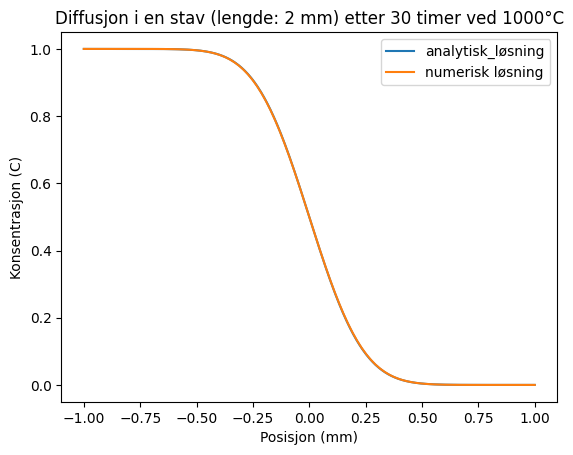

In [134]:
#løsning med finite difference metode, konstant diffusjonskoeffisient D og temp T

def sentral_diff(C, D, dx, D_list = None):
    if D_list is not None:
        # D midt mellom nodene:  D_{j+1/2} = (D_j + D_{j+1}) / 2
        D_flate = 0.5 * (D_list[:-1] + D_list[1:])
        # Ficks 1. lov på flatene:  J_{j+1/2} = -D_{j+1/2} * (C_{j+1} - C_j) / dx
        J = -D_flate * (C[1:] - C[:-1]) / dx        # C[1:] = C_{j+1},  C[:-1] = C_j
    else:
        J = -D * (C[1:] - C[:-1]) / dx

    #dC_j/dt = -(J_{j+1/2} - J_{j-1/2}) / dx
    ny = np.zeros_like(C)
    ny[1:-1] = -(J[1:] - J[:-1]) / dx           # J[1:] = J_{j+1/2},  J[:-1] = J_{j-1/2}
    return ny, J

def itterering_1(C,D,dx,t_slutt,alpha=0.4):
    #dt regnes fra stabilitet: alpha = D*dt/dx^2 <= 0.5
    dt = alpha * dx**2 / D
    tid = 0
    C = np.array(C, dtype=float)
    lagring = [C.copy()]
    while tid < t_slutt:
        dcdt, J = sentral_diff(C, D, dx)
        C = C + dt * dcdt 
        lagring.append(C.copy())
        tid += dt
    return lagring

#----------- Parametere -----------------
Gridpunkter = 100 #antall punkter
t_slutt = 3600 * 30 # timer
T = 1000 + 273 # K
L = 1e-3           # m, avstand fra sentrum til endene av staven


D0, Q = 2.0e-5, 197e3  # Tabell 2.2 i P&E, Cu* i Cu

# C_grid
konsentrasjoner = np.zeros(Gridpunkter)
konsentrasjoner[:Gridpunkter//2] = 1.0

# posisjoner
dx = 2*L / (Gridpunkter - 1)   # samme avstand som linspace gir
posisjoner = np.linspace(-L,L,Gridpunkter)
posisjoner_mange = np.linspace(-L,L,1000)
D = D_arrhenius(D0, Q, T)

analy = analytical_solution(posisjoner_mange, t_slutt, T)
num = itterering_1(konsentrasjoner,D,dx,t_slutt)

plt.plot(posisjoner_mange * 1e3,analy,label="analytisk_løsning")
plt.plot(posisjoner * 1e3,num[-1],label="numerisk løsning")   # num[-1] = siste tidssteg
plt.xlabel('Posisjon (mm)')
plt.ylabel('Konsentrasjon (C)')
plt.title(f'Diffusjon i en stav (lengde: {2*L*1e3:.0f} mm) etter {t_slutt/3600:.0f} timer ved {T-273}°C')
plt.legend()
plt.plot()





7624


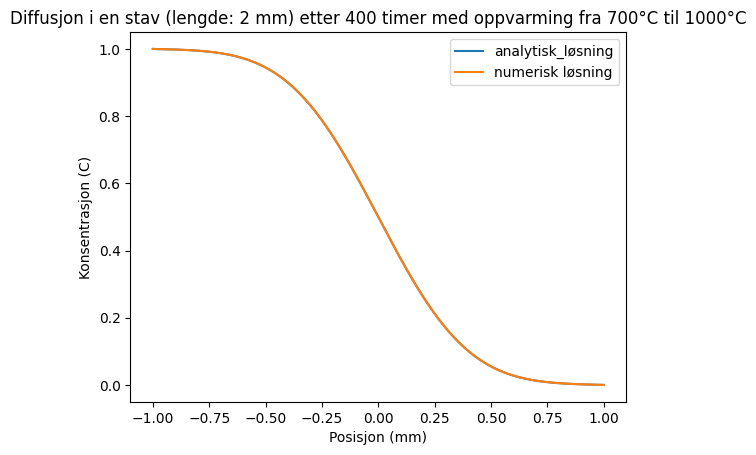

In [135]:
# Non isoterm anealing 

def itterering_anealing(C,T_start,T_end,dx,t_slutt,alpha=0.4):
    tid = 0
    DT_dt = (T_end - T_start) / t_slutt
    C = np.array(C, dtype=float)
    lagring = [C.copy()]
    itterasjoner = 0
    while tid < t_slutt:
        D = D_arrhenius(D0, Q, T_start + tid * DT_dt)
        dt = alpha * dx**2 / D
        dcdt, J = sentral_diff(C, D, dx)
        C = C + dt * dcdt 
        lagring.append(C.copy())
        tid += dt
        itterasjoner += 1
    print(itterasjoner)
    return lagring

def akkumulert_Dt(T_start, T_slutt, t_slutt, n=10000):
    t = np.linspace(0, t_slutt, n)
    T_av_t = T_start + (T_slutt - T_start) * t / t_slutt
    return np.trapezoid(D_arrhenius(D0, Q, T_av_t), t)

def analytisk_Anealing(x, Dt, M=500):
    """Samme rekke, men med akkumulert Dt i stedet for D*t."""
    C = 0.5 - x / (2 * L)
    for m in range(1, M + 1):
        C -= (1/(m*np.pi)) * np.sin(m*np.pi*x/L) * np.exp(-(m*np.pi/L)**2 * Dt)
    return C

#------------ Parametere -----------------
Gridpunkter = 500 #antall punkter
t_slutt = 3600 * 400 # timer
T = 1000 + 273 # K
L = 1e-3 # m, avstand fra sentrum til endene av staven
T_start = 700 + 273 # K
T_slutt = 1000 + 273 # K


D0, Q = 2.0e-5, 197e3  # Tabell 2.2 i P&E, Cu* i Cu

# C_grid
konsentrasjoner = np.zeros(Gridpunkter)
konsentrasjoner[:Gridpunkter//2] = 1.0

# posisjoner
dx = 2*L / (Gridpunkter - 1)   # samme avstand som linspace gir
posisjoner = np.linspace(-L,L,Gridpunkter)
posisjoner_mange = np.linspace(-L,L,1000)


Dt = akkumulert_Dt(T_start, T_slutt, t_slutt)   # erstatter D*t naar D ikke er konstant
analy = analytisk_Anealing(posisjoner_mange, Dt)
num = itterering_anealing(konsentrasjoner,T_start,T_slutt,dx,t_slutt)

plt.plot(posisjoner_mange * 1e3,analy,label="analytisk_løsning")
plt.plot(posisjoner * 1e3,num[-1],label="numerisk løsning")   # num[-1] = siste tidssteg
plt.xlabel('Posisjon (mm)')
plt.ylabel('Konsentrasjon (C)')
plt.title(f'Diffusjon i en stav (lengde: {2*L*1e3:.0f} mm) etter {t_slutt/3600:.0f} timer med oppvarming fra {T_start-273}°C til {T_slutt-273}°C')
plt.legend()
plt.show()


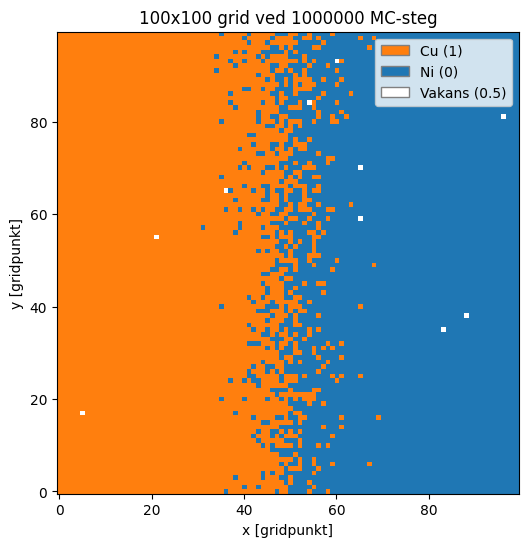

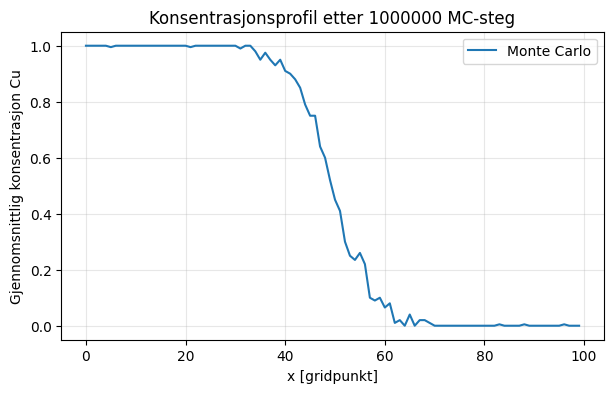

In [132]:
#Monte carlo tilnærming for å finne ficks første lov gjennom vakanser

#----------- Parametere -----------------
x_grid = 100
y_grid = 100
Monte_carlo_steg = 1e6
volum_vakans = 0.1 # prosent

Monte_carlo_steg = int(Monte_carlo_steg)
volum_vakans = volum_vakans/100

Grid = np.zeros((x_grid, y_grid)) 
Grid[:len(Grid)//2,:] = 1
antall_vakans = int(volum_vakans * x_grid * y_grid)
for i in range(antall_vakans):
    x = np.random.randint(0, x_grid)
    y = np.random.randint(0, y_grid)
    Grid[x, y] = 0.5

# ------------------ Monte carlo del -----------------------------
def Monte_carlo_diff(Grid, MC):
    vakanser = np.argwhere(Grid == 0.5)   # array med [x, y] for hver vakans
    #forhåndsgenerer noen verdier for rask kode
    valg = np.random.randint(0, len(vakanser), MC)
    dxs = np.random.choice([-1, 1], MC)
    dys = np.random.choice([-1, 1], MC)
    for i in range(MC):
        inx = valg[i]
        x, y = vakanser[inx]
        dx = dxs[i]
        dy = dys[i]
        if x + dx < 0 or x + dx >= x_grid:
            dx = 0
        if y + dy < 0 or y + dy >= y_grid:
            dy = 0
        nabo = Grid[x + dx, y + dy]
        if nabo != 0.5:                 # naboen er et atom (Cu eller Ni), ikke en annen vakans
            Grid[x, y] = nabo           # atomet flytter inn dit vakansen var
            Grid[x + dx, y + dy] = 0.5  # vakansen havner der atomet var
            vakanser[inx] = [x + dx, y + dy]  # oppdaterer posisjonen til vakansen
    return Grid

Grid = Monte_carlo_diff(Grid, Monte_carlo_steg)

# ---------------------- Plotting ----------------------
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# 0 = Ni (blaa), 0.5 = vakans (hvit), 1 = Cu (oransje)
farger = ListedColormap(['tab:blue', 'white', 'tab:orange'])
# grensene legges mellom verdiene, saa hver verdi faar sin egen farge
norm = BoundaryNorm([-0.25, 0.25, 0.75, 1.25], farger.N)

plt.figure(figsize=(6, 6))
plt.imshow(Grid.T, cmap=farger, norm=norm, origin='lower', interpolation='nearest')
plt.xlabel('x [gridpunkt]')
plt.ylabel('y [gridpunkt]')
plt.title(f'{x_grid}x{y_grid} grid ved {Monte_carlo_steg} MC-steg')
plt.legend(handles=[Patch(facecolor='tab:orange', edgecolor='grey', label='Cu (1)'),Patch(facecolor='tab:blue', edgecolor='grey', label='Ni (0)'),Patch(facecolor='white', edgecolor='grey', label='Vakans (0.5)')],loc='upper right')
plt.show()

#------------- Gjennomsnittskonsentrasjon per x-posisjon --------
# snittet over alle y for hver x, dvs. np.mean(Grid[i,:]) for i = 0..x_grid-1
snitt = Grid.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(x_grid), snitt, label='Monte Carlo')
plt.xlabel('x [gridpunkt]')
plt.ylabel('Gjennomsnittlig konsentrasjon Cu')
plt.title(f'Konsentrasjonsprofil etter {Monte_carlo_steg} MC-steg')
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

